# MLP from Scratch on MNIST


## MLP to classify handwritten digits

MNIST is a dataset of handwritten digits (0–9). Each image is $28 \times 28$ grayscale pixels and we want to classify it into one of 10 classes. We build a function $f_\theta : \mathbb{R}^{784} \to \mathbb{R}^{10}$ parameterized by weights $\theta = \{W_i, b_i\}_{i \in I}$.

For a 3-layer MLP (2 hidden + 1 output), the forward pass is:

$$
\begin{aligned}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
z &= W_3 h_2 + b_3
\end{aligned}
$$

##### Dimensions I choose for my Neural Network :

- Input: image of $28 \times 28 = 784$ pixels, flattened → $x \in \mathbb{R}^{784}$
- Hidden 1: $W_1 \in \mathbb{R}^{64 \times 784}$, $b_1 \in \mathbb{R}^{64}$ → $h_1 \in \mathbb{R}^{64}$
- Hidden 2: $W_2 \in \mathbb{R}^{32 \times 64}$, $b_2 \in \mathbb{R}^{32}$ → $h_2 \in \mathbb{R}^{32}$
- Output: $W_3 \in \mathbb{R}^{10 \times 32}$, $b_3 \in \mathbb{R}^{10}$ → $z \in \mathbb{R}^{10}$ 

**In batched form**, we pass $B$ samples at a time. The input becomes $X \in \mathbb{R}^{B \times 784}$ and the output $Z \in \mathbb{R}^{B \times 10}$.

![MLP Architecture](mlp_architecture.png)

## 2. Setup — imports

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

if device == 'cuda':
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3. Data — MNIST

MNIST contains 60 000 training images and 10 000 test images of handwritten digits, 28×28 grayscale.

Each pixel is in $[0, 255]$. We normalize to $[0, 1]$ with `transforms.ToTensor()`, which also converts to a `(1, 28, 28)` float tensor.

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

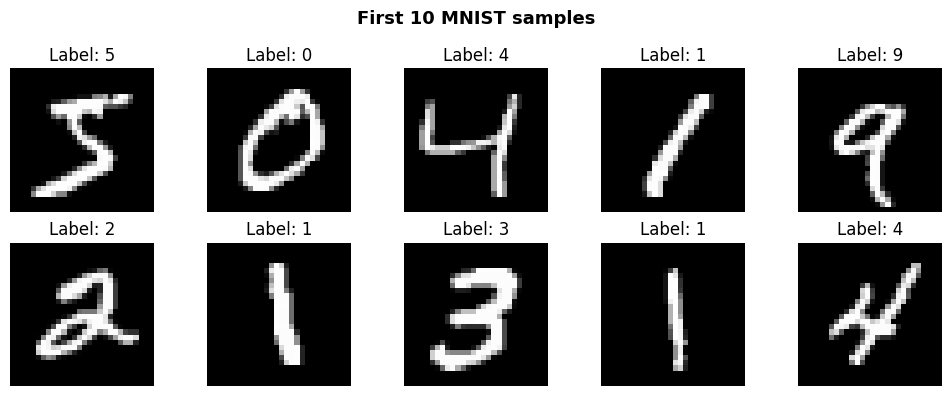

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.suptitle('First 10 MNIST samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. The Linear Layer

We implement a single fully-connected layer $f : \mathbb{R}^{d_\text{in}} \to \mathbb{R}^{d_\text{out}}$ defined by:

$$f(x) = x W^T + b \qquad W \in \mathbb{R}^{d_\text{out} \times d_\text{in}}, \quad b \in \mathbb{R}^{d_\text{out}}$$

### Weight initialization — He init

The choice of initial values for $W$ matters. If the weights are too large, activations explode through the layers. If too small, they vanish.

**He initialization** (Kaiming, 2015) sets:

$$W_{ij} \sim \mathcal{N}\!\left(0,\ \frac{2}{d_\text{in}}\right)$$

The factor $2$ comes from the ReLU activation, which zeroes out half the neurons on average, so the effective variance is halved at each layer. Multiplying by $2$ compensates for this.

In practice we sample from $\mathcal{N}(0, 1)$ and multiply by $\sigma = \sqrt{2 / d_\text{in}}$:

```python
W = torch.randn(out_features, in_features) * math.sqrt(2 / in_features)
```

**Why is this equivalent?** If $X \sim \mathcal{N}(0, 1)$ and $Y = \sigma X$, then:

$$\mathbb{E}[Y] = \sigma \,\mathbb{E}[X] = 0$$

$$\text{Var}(Y) = \sigma^2 \,\text{Var}(X) = \sigma^2 \cdot 1 = \sigma^2$$

Since $Y$ is a linear transform of a Gaussian, it is also Gaussian. Therefore:

$$Y \sim \mathcal{N}(0,\ \sigma^2) = \mathcal{N}\!\left(0,\ \frac{2}{d_\text{in}}\right)$$

The two sampling strategies are mathematically identical.

In [5]:
class LinearScratch:

    def __init__(self, in_features, out_features, device='cpu'):
        self.W = torch.randn(out_features, in_features, device=device) * math.sqrt(2 / in_features)
        self.W.requires_grad_(True)
        self.b = torch.zeros(out_features, device=device, requires_grad=True)

    def __call__(self, x):
        return x @ self.W.T + self.b

    def parameters(self):
        return [self.W, self.b]

## 5. The full MLP
We have : 
$$
\begin{aligned}
h_1 &= \text{ReLU}(W_1 x + b_1) \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \\
y &= W_3 h_2 + b_3
\end{aligned}
$$

In [6]:
class MLP:

    def __init__(self, device='cpu'):
        self.fc1 = LinearScratch(784, 64, device=device)
        self.fc2 = LinearScratch(64, 32, device=device)
        self.fc3 = LinearScratch(32, 10, device=device)

    def __call__(self, x):
        h1 = torch.relu(self.fc1(x))
        h2 = torch.relu(self.fc2(h1))
        y = self.fc3(h2)
        return y

    def parameters(self):
        return self.fc1.parameters() + self.fc2.parameters() + self.fc3.parameters()

## 6. The loss : Cross-Entropy

For classification we use **cross-entropy**. The output of our network is $Z \in \mathbb{R}^{B \times 10}$ — for each of the $B$ samples, we get a vector of 10 raw scores. We now turn them into a loss.

### Step 1 : Softmax

For sample $k$, we turn its score vector $z^{(k)} \in \mathbb{R}^{10}$ into a probability distribution:

$$p_i^{(k)} = \text{softmax}(z_i^{(k)}) = \frac{e^{z_i^{(k)}}}{\sum_{j=1}^{10} e^{z_j^{(k)}}}$$

### Step 2 : Negative log-likelihood

Given the true class $y^{(k)} \in \{0, 1, \dots, 9\}$, the loss for sample $k$ is:

$$\mathcal{L}_k = -\log p_{y^{(k)}}^{(k)}$$

### Combined : log-softmax + NLL

Computing softmax then taking the log is numerically unstable (the exponentials can overflow). Instead we use the **log-softmax trick**:

$$\log p_i^{(k)} = z_i^{(k)} - \log \sum_{j=1}^{10} e^{z_j^{(k)}}$$

The second term is computed with the **logsumexp trick**. Let $m = \max_{j \in \{1,\dots,10\}} z_j^{(k)}$:

$$\sum_{j=1}^{10} e^{z_j^{(k)}} = \sum_{j=1}^{10} e^{z_j^{(k)} - m + m} = e^m \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

Taking the log:

$$\log \sum_{j=1}^{10} e^{z_j^{(k)}} = m + \log \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

Since $z_j^{(k)} - m \leq 0$ for all $j$, every term $e^{z_j^{(k)} - m} \in ]0, 1]$ — no overflow possible.

So we have:

$$\mathcal{L}_k = - z_{y^{(k)}}^{(k)} + m + \log \sum_{j=1}^{10} e^{z_j^{(k)} - m}$$

### Final formula for a batch

The total loss is the average over the batch:

$$\mathcal{L} = \frac{1}{B} \sum_{k=1}^{B} \mathcal{L}_k = \frac{1}{B} \sum_{k=1}^{B} \left( \log \sum_{j=1}^{10} e^{z_j^{(k)} - m} - \left(z_{y^{(k)}}^{(k)} - m\right) \right)$$

In [7]:
def cross_entropy_scratch(logits, targets):
    
    B = logits.shape[0]

    m = logits.max(dim=1).values                  # (B,)
    stable_logits = logits - m.unsqueeze(1)       # (B, 10)
    
    log_sum_exp = stable_logits.exp().sum(dim=1).log()     # (B,)

    true_class_logits = logits[torch.arange(B), targets]   # (B,)

    lk = log_sum_exp -true_class_logits + m            # (B,)

    return lk.mean()

## 8. Optimizer : Stochastic Gradient Descent (SGD)

The gradient $\nabla_\theta \mathcal{L}$ tells us the direction in which the loss increases the most. To **minimize** the loss, we go in the opposite direction:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta \mathcal{L}(\theta_t)$$

where $\eta$ is the **learning rate** 


### The autograd workflow

1. **Forward pass** — compute logits and loss
2. **Backward pass** — call `loss.backward()`. PyTorch builds the computation graph during the forward pass and automatically computes $\nabla_\theta \mathcal{L}$ for every tensor with `requires_grad=True`. The gradients are stored in `p.grad`.
3. **Update** — apply $p \leftarrow p - \eta \cdot p.\text{grad}$
4. **Zero the gradients** — PyTorch *accumulates* gradients by default, so we must reset them before the next step

**Important:** the update must happen inside `torch.no_grad()` so it doesn't get tracked by autograd.

In [8]:
def sgd_step(params, lr):
    
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()


## 9. Training loop

For each epoch:
1. Iterate over batches of the training set
2. Forward → loss → backward → SGD step
3. Log the running loss
4. At the end of the epoch, evaluate on the test set

In [9]:
def evaluate(model, loader, device):
    
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.view(x.size(0), -1).to(device)  
            y = y.to(device)
            logits = model(x)                       
            preds = logits.argmax(dim=1)             
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [10]:
# Hyperparameters
EPOCHS = 10
LR = 0.05

model = MLP(device=device)
train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for x, y in train_loader:
        x = x.view(x.size(0), -1).to(device)   
        y = y.to(device)

        logits = model(x)                       
        loss = cross_entropy_scratch(logits, y)  

        loss.backward()                          
        sgd_step(model.parameters(), LR)        

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    test_acc = evaluate(model, test_loader, device)
    train_losses.append(avg_loss)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1:2d} | loss = {avg_loss:.4f} | test_acc = {test_acc:.4f}")

Epoch  1 | loss = 0.6064 | test_acc = 0.9154
Epoch  2 | loss = 0.2729 | test_acc = 0.9289
Epoch  3 | loss = 0.2211 | test_acc = 0.9415
Epoch  4 | loss = 0.1893 | test_acc = 0.9489
Epoch  5 | loss = 0.1668 | test_acc = 0.9525
Epoch  6 | loss = 0.1491 | test_acc = 0.9540
Epoch  7 | loss = 0.1348 | test_acc = 0.9583
Epoch  8 | loss = 0.1229 | test_acc = 0.9617
Epoch  9 | loss = 0.1136 | test_acc = 0.9633
Epoch 10 | loss = 0.1053 | test_acc = 0.9642


## 10. Learning curves

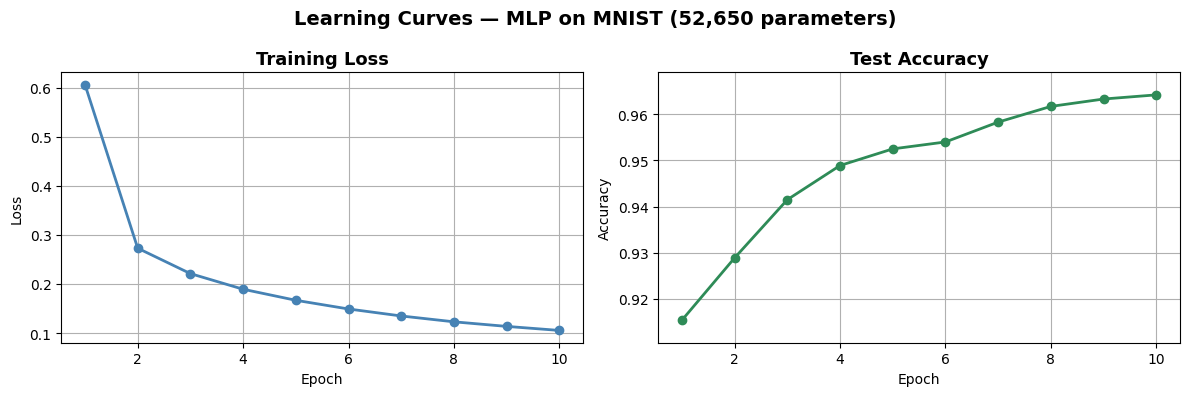

In [14]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, color='steelblue', linewidth=2, marker='o')
ax1.set_title('Training Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(epochs_range, test_accuracies, color='seagreen', linewidth=2, marker='o')
ax2.set_title('Test Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
margin = (max(test_accuracies) - min(test_accuracies)) * 0.1
ax2.set_ylim(min(test_accuracies) - margin, max(test_accuracies) + margin)
ax2.grid(True)

n_params = sum(p.numel() for p in model.parameters())
plt.suptitle(f'Learning Curves — MLP on MNIST ({n_params:,} parameters)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Visualize predictions

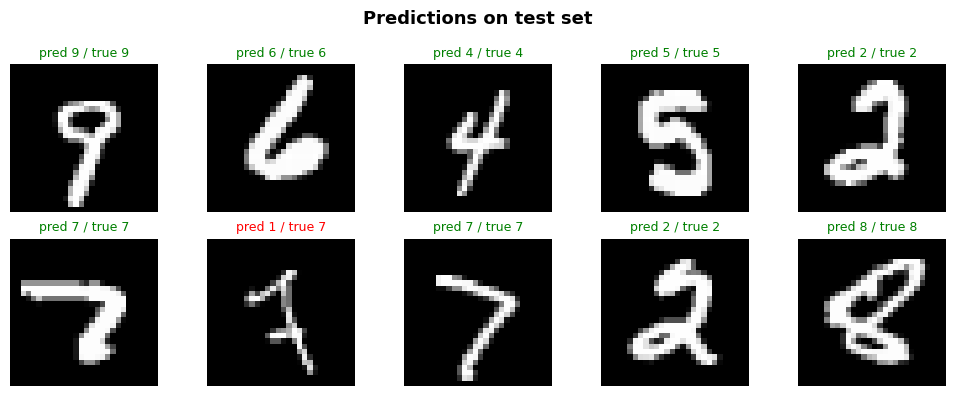

In [24]:
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, true_label = test_dataset[indices[i]]
    x = image.view(1, -1).to(device)              

    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()

    ax.imshow(image.squeeze(), cmap='gray')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f'pred {pred} / true {true_label}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Predictions on test set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. The PyTorch way

Same network, but using the standard `torch.nn` / `torch.optim` API instead of building everything from scratch. Each block shows what would have replaced our handmade version.

In [ ]:
# ============================================================================
# Imports we would add :
# ----------------------------------------------------------------------------
# import torch.nn as nn                  # all layer / loss / module classes
# import torch.nn.functional as F        # stateless versions (F.relu, F.cross_entropy, ...)
# import torch.optim as optim            # built-in optimizers (SGD, Adam, ...)
# ============================================================================


# ============================================================================
# Replaces LinearScratch (cell 9)
# ----------------------------------------------------------------------------
# fc = nn.Linear(in_features, out_features)
#   → creates W and b internally
#   → He init not by default : nn.init.kaiming_normal_(fc.weight, nonlinearity='relu')
# ============================================================================


# ============================================================================
# Replaces our MLP class (cell 11) — using nn.Module
# ----------------------------------------------------------------------------
# class MLP(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1 = nn.Linear(784, 64)
#         self.fc2 = nn.Linear(64, 32)
#         self.fc3 = nn.Linear(32, 10)
#
#     def forward(self, x):
#         h1 = F.relu(self.fc1(x))
#         h2 = F.relu(self.fc2(h1))
#         return self.fc3(h2)
#
# model = MLP().to(device)
#
# Or equivalently with nn.Sequential :
# model = nn.Sequential(
#     nn.Linear(784, 64), nn.ReLU(),
#     nn.Linear(64, 32),  nn.ReLU(),
#     nn.Linear(32, 10),
# ).to(device)
# ============================================================================


# ============================================================================
# Replaces cross_entropy_scratch (cell 13)
# ----------------------------------------------------------------------------
# loss = F.cross_entropy(logits, targets)
#   → already applies log-softmax + NLL with the logsumexp trick
#   → numerically stable, optimized C++ kernel
#
# Equivalent class-based form :
# criterion = nn.CrossEntropyLoss()
# loss = criterion(logits, targets)
# ============================================================================


# ============================================================================
# Replaces sgd_step (cell 15)
# ----------------------------------------------------------------------------
# optimizer = optim.SGD(model.parameters(), lr=0.05)
#
# In the training loop :
# optimizer.zero_grad()    # replaces p.grad.zero_()
# loss.backward()
# optimizer.step()         # replaces our manual p -= lr * p.grad
# ============================================================================


# ============================================================================
# Full PyTorch training loop (replaces cell 18)
# ----------------------------------------------------------------------------
# model = MLP().to(device)
# optimizer = optim.SGD(model.parameters(), lr=0.05)
# criterion = nn.CrossEntropyLoss()
#
# for epoch in range(EPOCHS):
#     model.train()
#     for x, y in train_loader:
#         x = x.view(x.size(0), -1).to(device)
#         y = y.to(device)
#
#         logits = model(x)
#         loss = criterion(logits, y)
#
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
# ============================================================================